In [4]:
import numpy as np
fruits = np.load('fruits_300.npy')
fruits_2d = fruits.reshape(-1, 100* 100)

In [7]:
# 차원 축소 : 차원 : 특성 갯수 
from sklearn.decomposition import PCA
pca = PCA(n_components=50)
pca.fit(fruits_2d)

,n_components,50
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [8]:
pca.components_.shape

(50, 10000)

In [16]:
# 10행 10열로 과일 이미지를 출력하는 함수 
import matplotlib.pyplot as plt

def draw_fruits(arr, ratio = 1): # arr : 과일 이미지 데이터 배열, ratio : 확대 비율
    # 총 샘플의 갯수 
    total = len(arr)
    # 총 행수
    rows = int(np.ceil(total / 10)) 

    # 한 행당 열의 갯수 
    cols = total if rows < 2 else 10 # 1행일때는 전체 갯수, 그 이상일때는 10개로 열 갯수 고정

    _, axs = plt.subplots(rows, cols, figsize=(cols * ratio, rows * ratio))

    for i in range(rows):
        for j in range(cols):
            cur = i * 10 + j
            if  cur < total:
                axs[i, j].imshow(arr[cur], cmap='gray_r', squeeze=False)
            
            axs[i,j].axis('off')
    plt.show()

AttributeError: AxesImage.set() got an unexpected keyword argument 'squeeze'

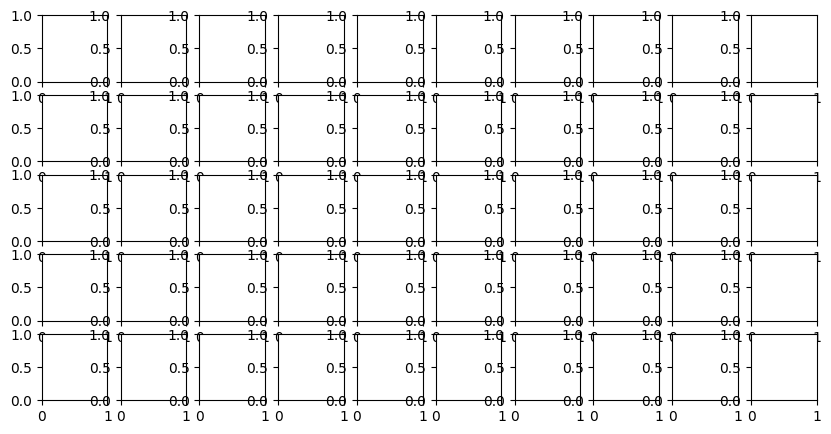

In [15]:
draw_fruits(pca.components_.reshape(-1, 100, 100))

In [ ]:
fruits_pca = pca.transform(fruits_2d) # 10000 차원 -> 50 차원
fruits_pca.shape

(300, 50)

In [19]:
# 원본 데이터 복구 - pca.inverse_transform(..) : 50 차원 -> 10000 차원 
fruits_inverse = pca.inverse_transform(fruits_pca)
fruits_inverse.shape

(300, 10000)

AttributeError: AxesImage.set() got an unexpected keyword argument 'squeeze'

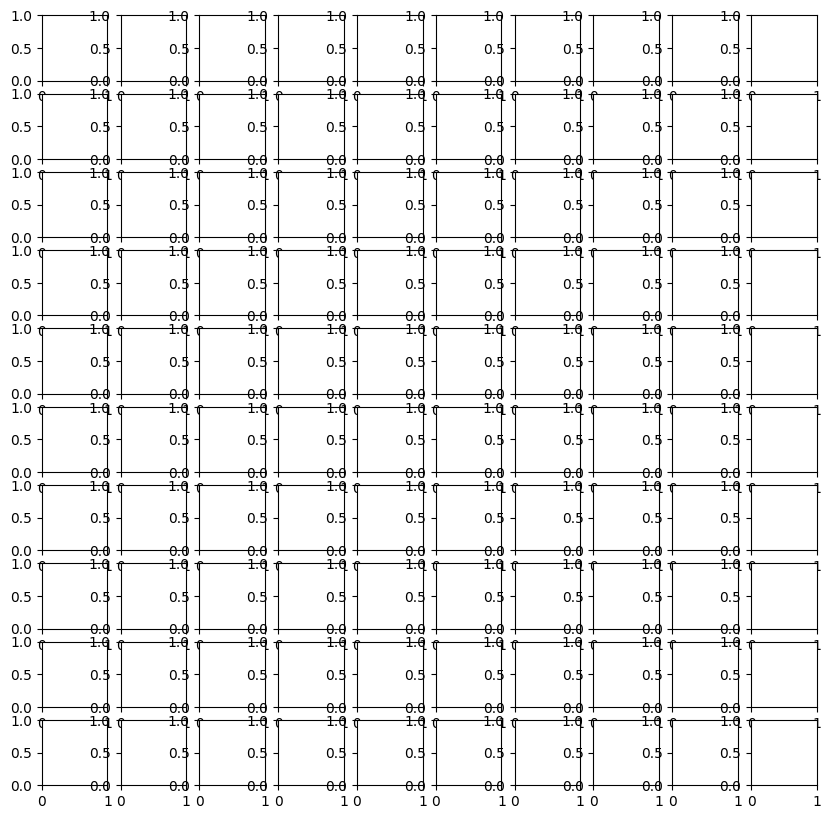

In [23]:
fruits_reconstruct = fruits_inverse.reshape(-1, 100*100)
for i in [0, 100, 200]:
    draw_fruits(fruits_reconstruct[i:i+100])


In [22]:
# 설명된 분산 , 주성분이 원본데이터를 얼마만큼 설명 할 수 있는지 (복구 기능 비율)
# pca.explained_variance_ratio
np.sum(pca.explained_variance_ratio_)

np.float64(0.9214818368615356)

In [24]:
pca.explained_variance_ratio_

array([0.42357017, 0.09941755, 0.06577863, 0.04031172, 0.03416875,
       0.03281329, 0.02573267, 0.02054963, 0.01372276, 0.01342773,
       0.01152146, 0.00944596, 0.00878232, 0.00846697, 0.00693049,
       0.00645188, 0.00578895, 0.00511203, 0.00486383, 0.00480345,
       0.00447836, 0.00437314, 0.0040804 , 0.00389476, 0.00372438,
       0.00359276, 0.00331443, 0.00317794, 0.00304321, 0.00303708,
       0.00288906, 0.00275884, 0.00264951, 0.00255823, 0.00252072,
       0.00246944, 0.00239677, 0.0023097 , 0.0022169 , 0.00216446,
       0.0021396 , 0.00194497, 0.00191298, 0.00190538, 0.00184274,
       0.00182821, 0.00173022, 0.00166352, 0.00160879, 0.0015951 ])

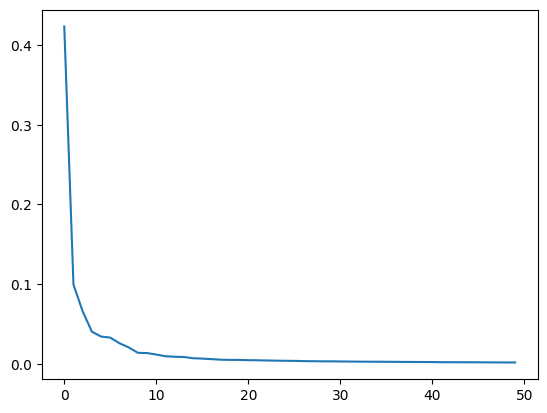

In [ ]:
plt.plot(pca.explained_variance_ratio_) # explained 분산 차원 축소 나 모델 해석과 관련 것 
plt.show()

In [28]:
target  = np.array([0]* 100 +[1] * 100 +[2]* 100)


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

In [33]:
lr = LogisticRegression()
cv = cross_validate(lr, fruits_2d, target)
print("걸린시간:", np.mean(cv['fit_time']))
print("정확도:", np.mean(cv['test_score']))



걸린시간: 0.28258585929870605
정확도: 0.9966666666666667


In [ ]:
lr = LogisticRegression()
cv= cross_validate(lr, fruits_pca, target) # 50개로 차원 축소한 데이터
print("걸린시간:", np.mean(cv['fit_time']))
print("정확도:", np.mean(cv['test_score']))

걸린시간: 0.008562707901000976
정확도: 0.9966666666666667


In [36]:
# n_components = 0~1 미만 값 설명된 분산비율 
pca = PCA(n_components=0.5)
pca.fit(fruits_2d)
pca.components_.shape

(2, 10000)

In [37]:
fruits_pca= pca.transform(fruits_2d)
fruits_pca.shape

(300, 2)

In [38]:
lr = LogisticRegression()
cv = cross_validate(lr, fruits_2d, target) # 2개로 차원 축소 데이터
print("걸린시간:", np.mean(cv['fit_time']))
print("정확도:", np.mean(cv['test_score']))


걸린시간: 0.26470108032226564
정확도: 0.9966666666666667


In [45]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3, random_state=42)
km.fit(fruits_pca)


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [46]:
np.unique(km,labels_, return_counts=True)

NameError: name 'labels_' is not defined

TypeError: legend() takes 0-2 positional arguments but 3 were given

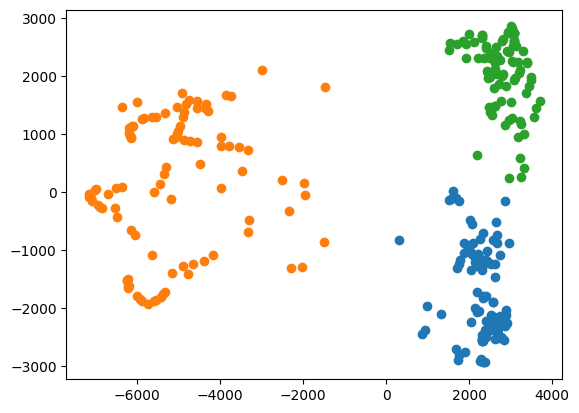

In [48]:
for labels in range(0,3):
    data = fruits_pca[km.labels_ == labels]
    plt.scatter(data[:,0], data[:,1])

plt.legend('pineapple', 'banana', 'apple')
plt.show()